In [145]:
# --- Step 1: Load required libraries ---
library(ggpubr)
library(dplyr)

# --- Step 1: Load WGS telomere data ---
wgs <- read.table("/tgen_labs/barthel/public_datasets/TCGA/telomere_length/WGS-Paired_set.txt",
                  header = TRUE, sep = "\t", stringsAsFactors = FALSE)

# --- Step 2: Load aneuploidy/CNV data ---
sample_scores <- read.table("/tgen_labs/barthel/public_datasets/TCGA/cnv/PCTL.snp6.segmented_scna_minus_germline.hg19.seg.txt",
                            header = TRUE, sep = "\t", stringsAsFactors = FALSE)

# --- Step 3: Standardize patient IDs ---
sample_scores$patient_id <- sub("^(TCGA-[A-Z0-9]{2}-[0-9]{4}).*", "\\1", sample_scores$Sample)
wgs$patient_id <- sub("^(TCGA-[A-Z0-9]{2}-[0-9]{4}).*", "\\1", wgs$SampleID)

# --- Step 4: Merge TL and aneuploidy data ---
merged_all <- merge(wgs, sample_scores, by = "patient_id", all.x = TRUE)

# --- Step 5: Filter for GBM, Oligodendroglioma, Astrocytoma ---
merged_sub <- merged_all %>%
  filter(Disease %in% c("GBM", "LGG"))



In [146]:
head(sample_scores)

,Sample,Chromosome,Start,End,Num_Probes,Segment_Mean,patient_id
,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>
1,TCGA-RZ-AB0B-10A-01D-A39Y-01,1,3218610,105104370,58531,0.0017,TCGA-RZ-AB0B-10A-01D-A39Y-01
2,TCGA-RZ-AB0B-10A-01D-A39Y-01,1,105105350,105164486,29,-1.0825,TCGA-RZ-AB0B-10A-01D-A39Y-01
3,TCGA-RZ-AB0B-10A-01D-A39Y-01,1,105173095,247813706,70525,-0.0019,TCGA-RZ-AB0B-10A-01D-A39Y-01
4,TCGA-RZ-AB0B-10A-01D-A39Y-01,2,484222,37464085,22113,0.0019,TCGA-RZ-AB0B-10A-01D-A39Y-01
5,TCGA-RZ-AB0B-10A-01D-A39Y-01,2,37464511,37464743,2,-1.4060,TCGA-RZ-AB0B-10A-01D-A39Y-01
6,TCGA-RZ-AB0B-10A-01D-A39Y-01,2,37468065,74146977,20863,0.0050,TCGA-RZ-AB0B-10A-01D-A39Y-01


In [147]:
# Check unique tumor types in your merged data
unique(merged_sub$Disease)


[1] "GBM" "LGG"

In [148]:
# --- Step 1: Load WGS telomere data ---
IDs <- read.table("/home/mjehangir/telomere-sv-analysis/notebooks/tcga_analysis/glioma_status.txt",
                  header = TRUE, sep = "\t", stringsAsFactors = FALSE)

In [149]:
head(IDs)

,WT,Non.codel,codel
,<chr>,<chr>,<chr>
1,TCGA-CS-4941,TCGA-CS-4938,TCGA-CS-5390
2,TCGA-CS-5395,TCGA-CS-4942,TCGA-CS-5396
3,TCGA-CS-5397,TCGA-CS-4943,TCGA-CS-6668
4,TCGA-CS-6186,TCGA-CS-4944,TCGA-CS-6670
5,TCGA-CS-6188,TCGA-CS-5393,TCGA-DB-5274
6,TCGA-CS-6669,TCGA-CS-5394,TCGA-DB-5278


In [150]:
head(merged_sub)
nrow(merged_sub)

,patient_id,SampleID,Disease,Center,LibraryType,PatientID,PairType,nTL,tTL,TLratio,⋯,ATRXDAXXstatus,TERTstatus,TERTalt,TERTexpr.ATRX.DAXXaltgrp,Sample,Chromosome,Start,End,Num_Probes,Segment_Mean
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>
1,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,ATRX/DAXX alt,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,9,132293507,132294278,6,0.0262
2,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,ATRX/DAXX alt,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,1,3218610,5101936,1257,-0.1771
3,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,ATRX/DAXX alt,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,9,135792178,136560244,449,0.9149
4,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,ATRX/DAXX alt,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,9,90468388,90469000,2,-1.1426
5,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,ATRX/DAXX alt,,,TERT expr,TCGA-02-2483-10A-01D-0784-01,16,653459,89379936,40797,0.0003
6,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,ATRX/DAXX alt,,,TERT expr,TCGA-02-2483-10A-01D-0784-01,22,17423930,49331012,16927,-0.0007


[1] 17798

In [151]:
# Assuming your tables are called:
# IDs: columns = WT, Non.codel, codel
# merged_sub: columns include patient_id

# 1. Create a lookup table: convert IDs table from wide to long
library(dplyr)
library(tidyr)

IDs_long <- IDs %>%
  pivot_longer(
    cols = everything(),
    names_to = "subtype",
    values_to = "patient_id"
  )

# 2. Map subtype to merged_sub using left_join
merged_sub <- merged_sub %>%
  left_join(IDs_long, by = "patient_id")

# 3. Now merged_sub has a new column 'subtype' with values: "WT", "Non.codel", "codel"
# Check the first rows
head(merged_sub)


,patient_id,SampleID,Disease,Center,LibraryType,PatientID,PairType,nTL,tTL,TLratio,⋯,TERTstatus,TERTalt,TERTexpr.ATRX.DAXXaltgrp,Sample,Chromosome,Start,End,Num_Probes,Segment_Mean,subtype
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>
1,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,9,132293507,132294278,6,0.0262,Non.codel
2,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,1,3218610,5101936,1257,-0.1771,Non.codel
3,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,9,135792178,136560244,449,0.9149,Non.codel
4,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,9,90468388,90469000,2,-1.1426,Non.codel
5,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-10A-01D-0784-01,16,653459,89379936,40797,0.0003,Non.codel
6,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-10A-01D-0784-01,22,17423930,49331012,16927,-0.0007,Non.codel


In [152]:
colnames(merged_sub)

[1] "patient_id"               "SampleID"                
 [3] "Disease"                  "Center"                  
 [5] "LibraryType"              "PatientID"               
 [7] "PairType"                 "nTL"                     
 [9] "tTL"                      "TLratio"                 
[11] "isCore"                   "isExtended"              
[13] "Age"                      "Gender"                  
[15] "OS"                       "S"                       
[17] "TERCexpr"                 "TERTexpr"                
[19] "ATRXexpr"                 "TERRAexpr"               
[21] "TERTamp"                  "TERCamp"                 
[23] "ATRXdel"                  "TP53del"                 
[25] "TP53mut"                  "ATRXmut"                 
[27] "TERTsv"                   "TERTpsv"                 
[29] "ATRXsv"                   "TERTpmut"                
[31] "TERTpmutsite"             "TERTpMethylationStatus"  
[33] "TelomeraseSignatureScore" "TERTfus"                 
[35] "ATRXfus"                  "TERTexprStatus"          
[37] "TERCstatus"               "ATRXstatus"              
[39] "DAXXstatus"               "ATRXDAXXstatus"          
[41] "TERTstatus"               "TERTalt"                 
[43] "TERTexpr.ATRX.DAXXaltgrp" "Sample"                  
[45] "Chromosome"               "Start"                   
[47] "End"                      "Num_Probes"              
[49] "Segment_Mean"             "subtype"

In [153]:
library(dplyr)

# Keep only telomere info, CNV segments, identifiers, and subtype
merged_simple <- merged_sub %>%
  select(
    patient_id, SampleID, subtype.x,  # identifiers and subtype
    nTL, tTL, TLratio,                          # telomere info
    Chromosome, Start, End, Segment_Mean  # CNV segment info
  ) %>%
  rename(subtype = subtype.x)  # optional: rename for simplicity

# Check the first few rows
head(merged_simple)



ERROR: [1m[33mError[39m in `select()`:[22m
[33m![39m Can't select columns that don't exist.
[31m✖[39m Column `subtype.x` doesn't exist.


In [ ]:
nrow(merged_simple)

In [ ]:
# Load required libraries
library(dplyr)
library(readr)

# -------------------------------
# 1. Read chromosome arm coordinates
# -------------------------------
path <- "/home/mjehangir/softwares/Arm-Level-Aneuploidy/data/genomic_arm_coordinates_hg19.txt"

arm_lengths <- read_tsv(path, col_types = cols(), comment = "#") %>%
  rename(arm_start = start, arm_end = end) %>%
  mutate(
    chrom = ifelse(grepl("^chr", chrom), chrom, paste0("chr", chrom)),
    arm_length = arm_end - arm_start
  ) %>%
  select(chrom, side, arm_start, arm_end, arm_length)

# -------------------------------
# 2. Prepare CNV + telomere table
# -------------------------------
# Assuming your table is called merged_simple
# with columns: patient_id, SampleID, subtype, nTL, tTL, TLratio, Chromosome, Start, End, Segment_Mean

merged_simple <- merged_simple %>%
  mutate(chrom = paste0("chr", Chromosome))  # ensure 'chr' prefix matches arm_lengths

# -------------------------------
# 3. Assign chromosome arms (p/q) based on overlap
# -------------------------------
merged_with_arm <- merged_simple %>%
  rowwise() %>%
  mutate(
    arm = {
      temp <- arm_lengths %>%
        filter(
          chrom == chrom,
          End >= arm_start,  # segment end after arm start
          Start <= arm_end   # segment start before arm end
        )
      if(nrow(temp) >= 1) temp$side[1] else NA_character_  # pick first overlapping arm
    }
  ) %>%
  ungroup()

# -------------------------------
# 4. Create chr_arm identifier
# -------------------------------
merged_with_arm <- merged_with_arm %>%
  mutate(chr_arm = paste0(chrom, arm))

# -------------------------------
# 5. Add arm size
# -------------------------------
merged_with_arm <- merged_with_arm %>%
  left_join(
    arm_lengths %>%
      select(chrom, side, arm_start, arm_end) %>%
      rename(arm = side),
    by = c("chrom", "arm")
  ) %>%
  mutate(arm_size = arm_end - arm_start) %>%
  select(-arm_start, -arm_end)  # optional, keep only arm_size

# -------------------------------
# 6. Check the result
# -------------------------------
head(merged_with_arm)


In [ ]:
nrow(merged_with_arm)

In [ ]:
nrow(arm_summary)

In [ ]:
library(dplyr)
library(tidyr)

# -------------------------------
# PARAMETERS
# -------------------------------
aneuploidy_threshold <- 0.80      # fraction of arm altered to call "Aneuploid"
segmean_threshold    <- 0.15    # |Segment_Mean| to mark segment as altered

# -------------------------------
# 1. Prepare table: merged_with_arm
# -------------------------------
# Ensure columns: patient_id, SampleID, chr_arm, arm_size, Start, End, Segment_Mean, subtype, nTL, tTL, TLratio
merged_for_arms <- merged_with_arm %>%
  select(patient_id, SampleID, chr_arm, arm_size, Start, End, Segment_Mean, subtype, nTL, tTL, TLratio) %>%
  mutate(
    seg_size = End - Start,
    altered_seg = abs(Segment_Mean) >= segmean_threshold
  )

# -------------------------------
# 2. Aggregate per patient per arm
# -------------------------------
arm_summary <- merged_for_arms %>%
  group_by(patient_id, SampleID, chr_arm, arm_size, subtype, nTL, tTL, TLratio) %>%
  summarise(
    altered_bp = sum(seg_size[altered_seg], na.rm = TRUE),
    frac_altered = altered_bp / first(arm_size),
    mean_segmean = mean(Segment_Mean, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    arm_status = case_when(
      frac_altered >= aneuploidy_threshold ~ "Aneuploid",
      frac_altered > 0 ~ "Segmental",
      TRUE ~ "Neutral"
    )
  )

# -------------------------------
# 3. Check result
# -------------------------------
head(arm_summary)


In [ ]:


length(unique(arm_summary$patient_id))


In [162]:
library(dplyr)
library(ggplot2)
library(ggforce)      # for sina
library(ggpubr)       # for p-values and correlations
library(readr)

# --------------------------------------------------------
# 1. LOAD DATA
# --------------------------------------------------------
# arm_summary <- read_tsv("arm_summary.tsv")   # <--- Use your file here

# Example: If already in environment, continue.

# --------------------------------------------------------
# 2. CALCULATE ANEUPLOIDY SCORE PER SAMPLE
# --------------------------------------------------------

arm_scores <- arm_summary %>%
  group_by(SampleID) %>%
  summarise(aneuploidy_score = sum(arm_status == "Aneuploid", na.rm = TRUE))

# --------------------------------------------------------
# 3. CALCULATE SEGMENTAL CNV BURDEN PER SAMPLE
# --------------------------------------------------------
# "Segmental" defined by arm_status == "Segmental"
# Using frac_altered column (already fraction per arm)

segmental_scores <- arm_summary %>%
  filter(arm_status == "Segmental") %>%
  group_by(SampleID) %>%
  summarise(segmental_cnv_burden = sum(frac_altered, na.rm = TRUE))

# --------------------------------------------------------
# 4. MERGE ANEUPLOIDY + SEGMENTAL SCORES BACK
# --------------------------------------------------------

df <- arm_summary %>%
  left_join(arm_scores, by = "SampleID") %>%
  left_join(segmental_scores, by = "SampleID") %>%
  distinct(SampleID, .keep_all = TRUE) %>%   # one row per sample
  drop_na(subtype, nTL, tTL, TLratio)


# --------------------------------------------------------
# 8. SAVE ALL PLOTS (optional)
# --------------------------------------------------------
# ggsave("p1_TLratio_by_subtype.pdf", p1, width = 6, height = 5)
# ggsave("p2_TLratio_vs_aneuploidy.pdf", p2, width = 7, height = 5)
# ggsave("p3_TLratio_vs_segmental.pdf", p3, width = 7, height = 5)


In [169]:
library(ggpubr)
library(ggplot2)
library(dplyr)

# ------------------------
# Prepare label positions
# ------------------------
label_y <- df %>%
  group_by(subtype) %>%
  summarise(max_y = max(TLratio, na.rm = TRUE)) %>%
  pull(max_y) + 0.05  # adjust spacing for stars




Warning message in wilcox.test.default(c(-0.18, -1.05, 0.51, 0.24, 0.34, 0.74, 0.66, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(-0.18, -1.05, 0.51, 0.24, 0.34, 0.74, 0.66, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.88, -0.09, -0.87, -1.05, 0.02, -0.15, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(-0.18, -1.05, 0.51, 0.24, 0.34, 0.74, 0.66, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(-0.18, -1.05, 0.51, 0.24, 0.34, 0.74, 0.66, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.88, -0.09, -0.87, -1.05, 0.02, -0.15, :
“cannot compute exact p-value with ties”


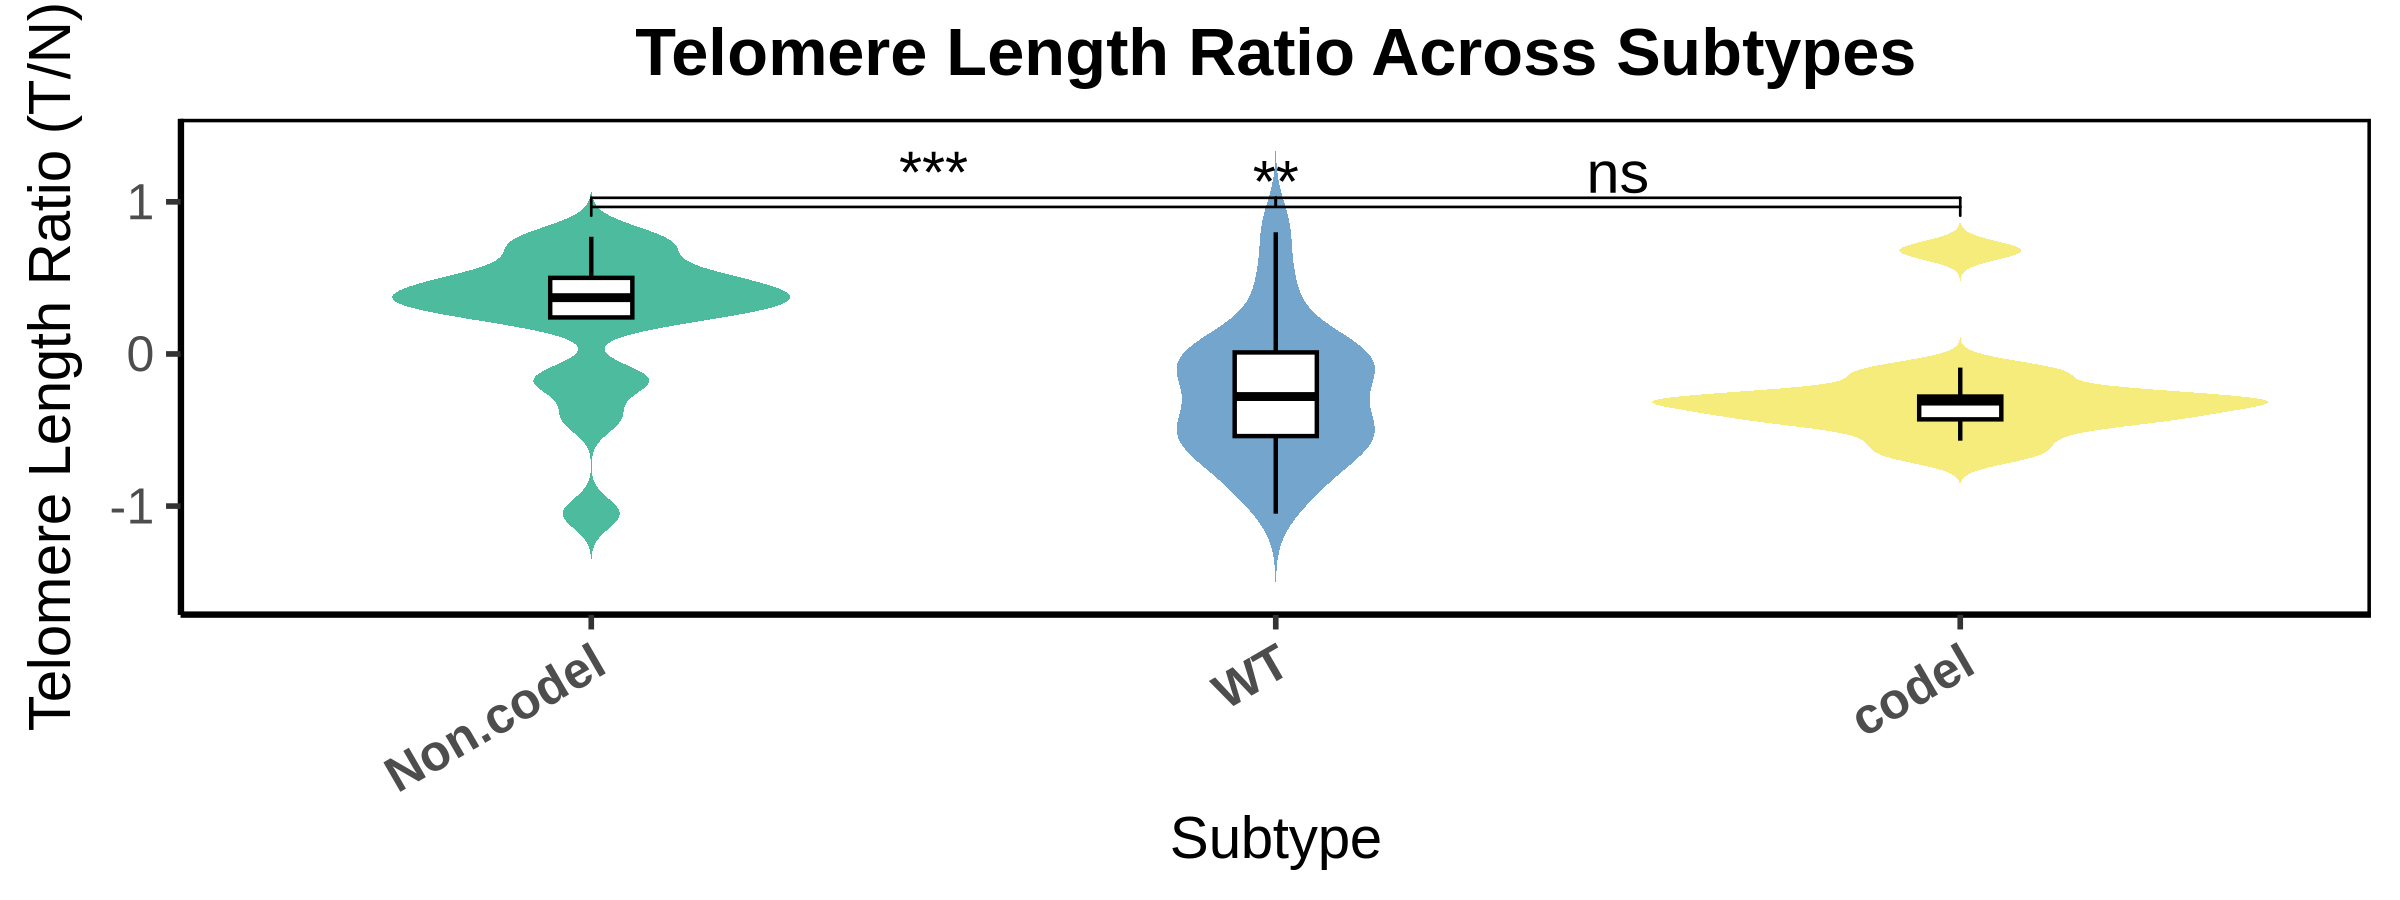

In [175]:
library(ggplot2)
library(ggpubr)
library(dplyr)
library(forcats)

# ------------------------
# Ensure subtype is a factor with proper order
# ------------------------
df$subtype <- factor(df$subtype, levels = c("Non.codel", "WT", "codel"))

# ------------------------
# Define pairwise comparisons for Wilcoxon test
# ------------------------
my_comparisons <- list(
  c("Non.codel", "WT"),
  c("WT", "codel"),
  c("Non.codel", "codel")
)

# ------------------------
# Compute label positions for each comparison
# ------------------------
label_y <- c(
  max(df$TLratio[df$subtype %in% c("Non.codel", "WT")], na.rm = TRUE) + 0.05,
  max(df$TLratio[df$subtype %in% c("WT", "codel")], na.rm = TRUE) + 0.05,
  max(df$TLratio[df$subtype %in% c("Non.codel", "codel")], na.rm = TRUE) + 0.10
)

# ------------------------
# Publication-ready Violin + Boxplot
# ------------------------
p1 <- ggplot(df, aes(x = subtype, y = TLratio, fill = subtype)) +
  
  # Violin plot
  geom_violin(trim = FALSE, alpha = 0.7, color = NA) +
  
  # Boxplot inside violin
  geom_boxplot(width = 0.12, fill = "white", outlier.shape = NA, color = "black") +
  
  # Wilcoxon significance test
  stat_compare_means(
    comparisons = my_comparisons,
    method = "wilcox.test",
    label = "p.signif",
    label.y = label_y,
    size = 5,
    tip.length = 0.03
  ) +
  
  # Custom color palette
  scale_fill_manual(values = c(
    "Non.codel" = "#009E73",
    "WT"        = "#377EB8",
    "codel"     = "#F0E442"
  )) +
  
  # Labels
  labs(
    y = "Telomere Length Ratio (T/N)",
    x = "Subtype",
    title = "Telomere Length Ratio Across Subtypes"
  ) +
  
  # Publication-ready theme
  theme_classic(base_size = 14) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 30, hjust = 1, size = 12, face = "bold"),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    panel.border = element_rect(color = "black", fill = NA, size = 0.8)
  )
p1
# ------------------------
# Save high-resolution figure
# ------------------------
ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig1/TelomereRatio_Subtype.pdf", p1, width = 4, height = 4, dpi = 600)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


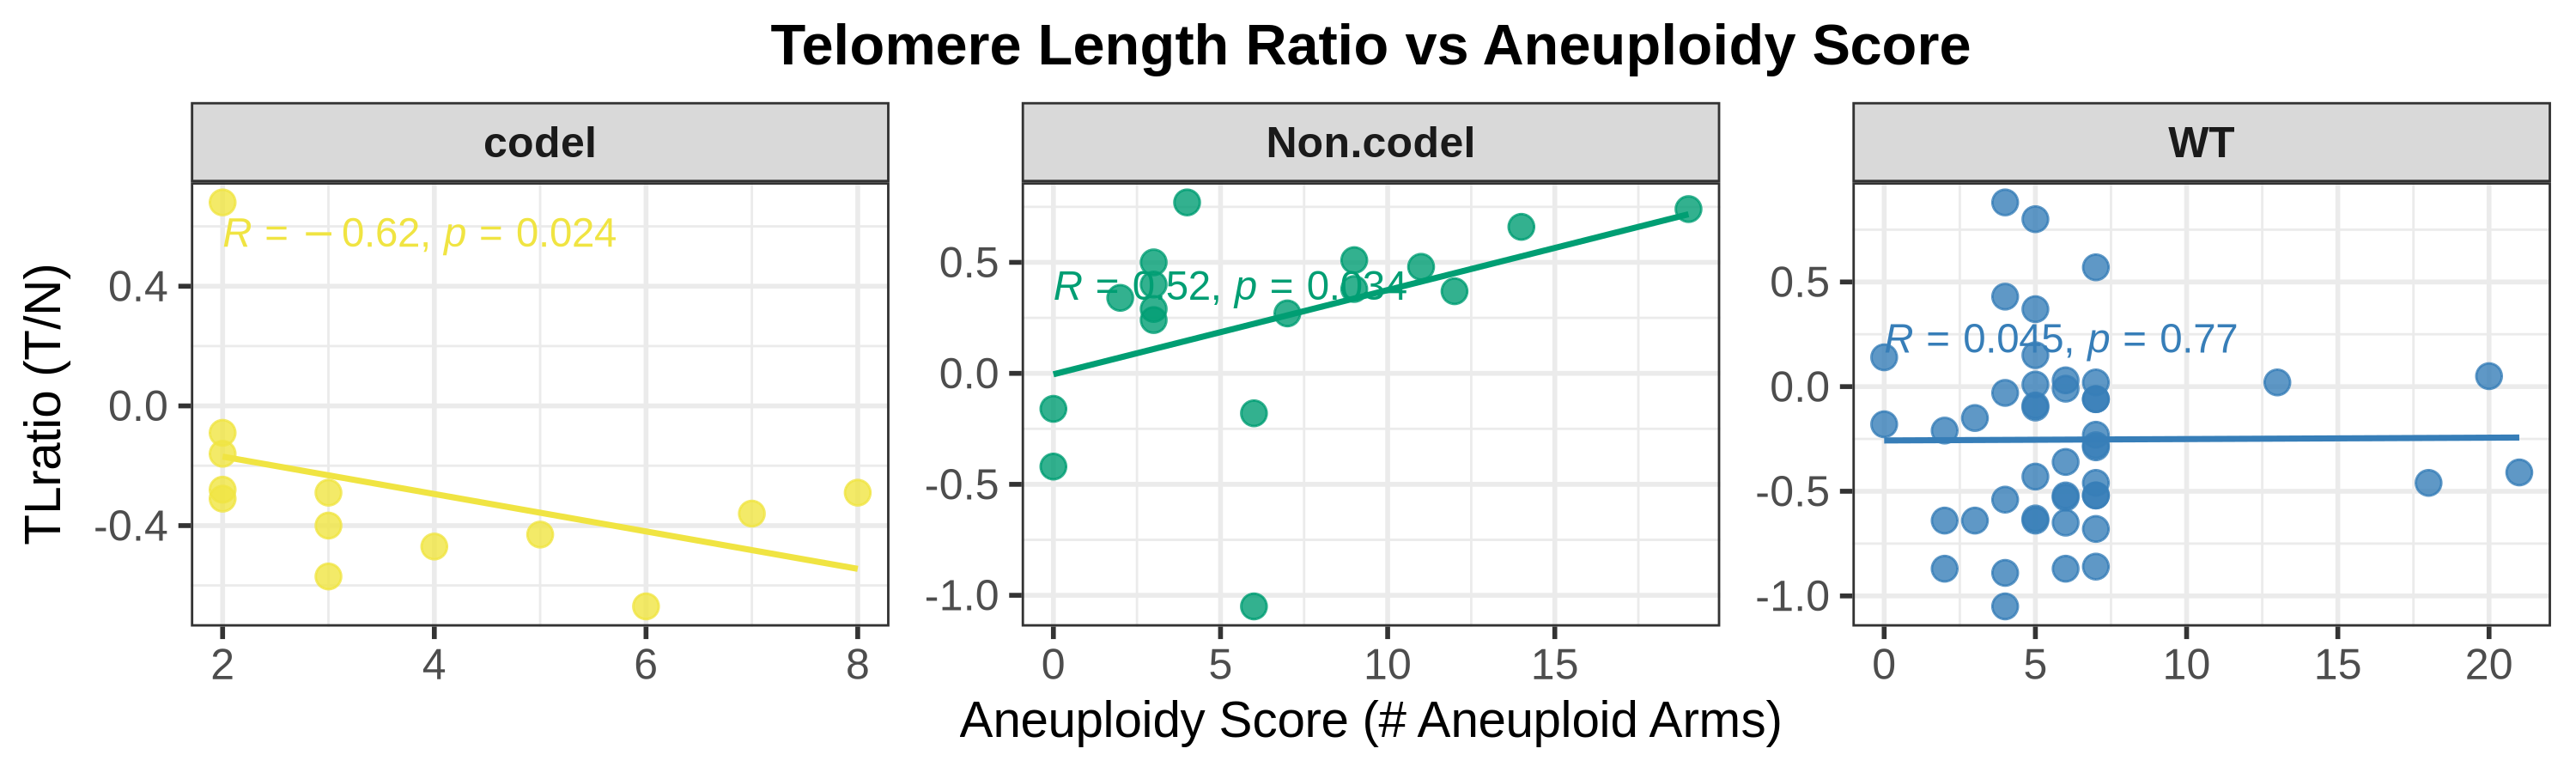

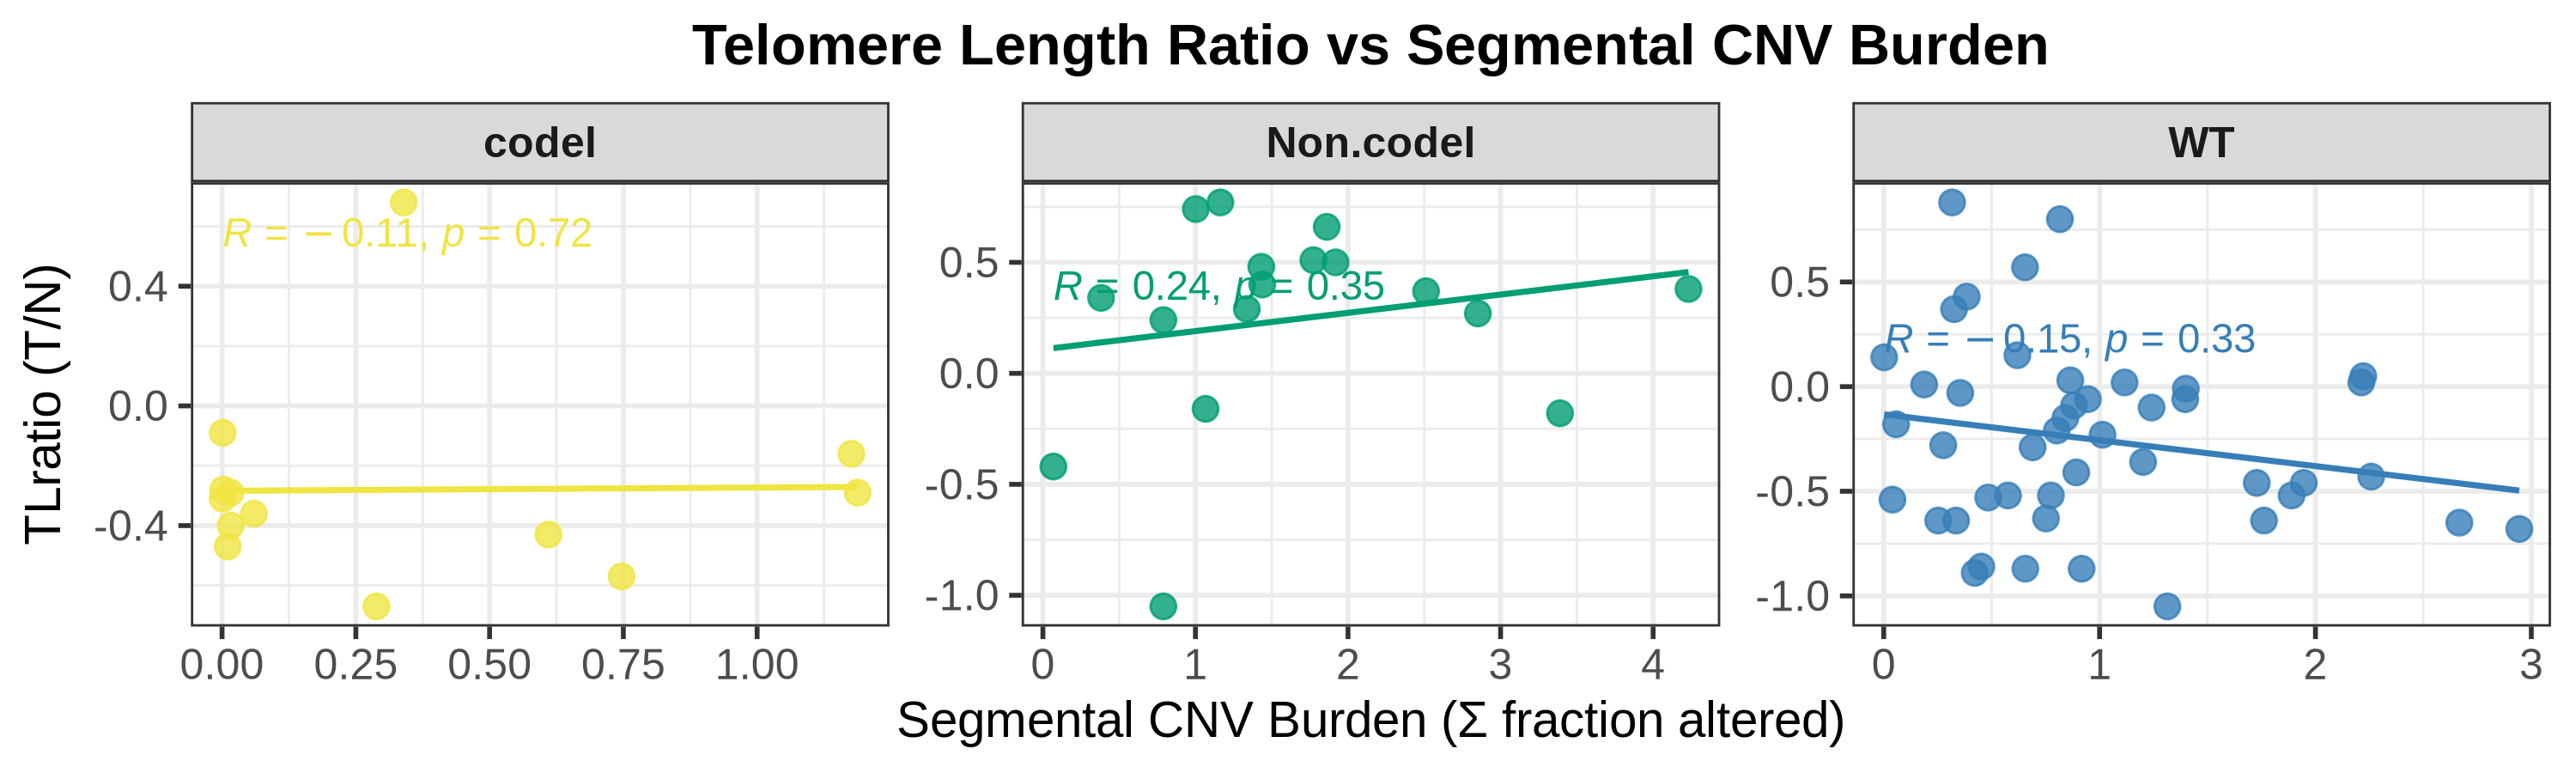

In [160]:
library(ggplot2)
library(ggpubr)

# Custom colors (same as P1)
subtype_colors <- c(
  "Non.codel" = "#009E73",
  "WT"        = "#377EB8",
  "codel"     = "#F0E442"
)

# ------------------------
# PLOT 2 — TLratio vs Aneuploidy Score
# ------------------------
p2 <- ggplot(df, aes(x = aneuploidy_score, y = TLratio, color = subtype)) +
  geom_point(size = 3, alpha = 0.8) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
  facet_wrap(~ subtype, scales = "free") +
  stat_cor(method = "spearman", label.x.npc = "left", label.y.npc = "top", size = 4) +
  scale_color_manual(values = subtype_colors) +
  labs(
    title = "Telomere Length Ratio vs Aneuploidy Score",
    x = "Aneuploidy Score (# Aneuploid Arms)",
    y = "TLratio (T/N)"
  ) +
  theme_bw(base_size = 14) +
  theme(
    strip.text = element_text(face = "bold", size = 12),
    legend.position = "none",
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5)
  )

# ------------------------
# PLOT 3 — TLratio vs Segmental CNV Burden
# ------------------------
p3 <- ggplot(df, aes(x = segmental_cnv_burden, y = TLratio, color = subtype)) +
  geom_point(size = 3, alpha = 0.8) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
  facet_wrap(~ subtype, scales = "free") +
  stat_cor(method = "spearman", label.x.npc = "left", label.y.npc = "top", size = 4) +
  scale_color_manual(values = subtype_colors) +
  labs(
    title = "Telomere Length Ratio vs Segmental CNV Burden",
    x = "Segmental CNV Burden (Σ fraction altered)",
    y = "TLratio (T/N)"
  ) +
  theme_bw(base_size = 14) +
  theme(
    strip.text = element_text(face = "bold", size = 12),
    legend.position = "none",
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5)
  )

#
options(repr.plot.width = 10, repr.plot.height = 3, repr.plot.res = 300)

# Display plots
p2
p3


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


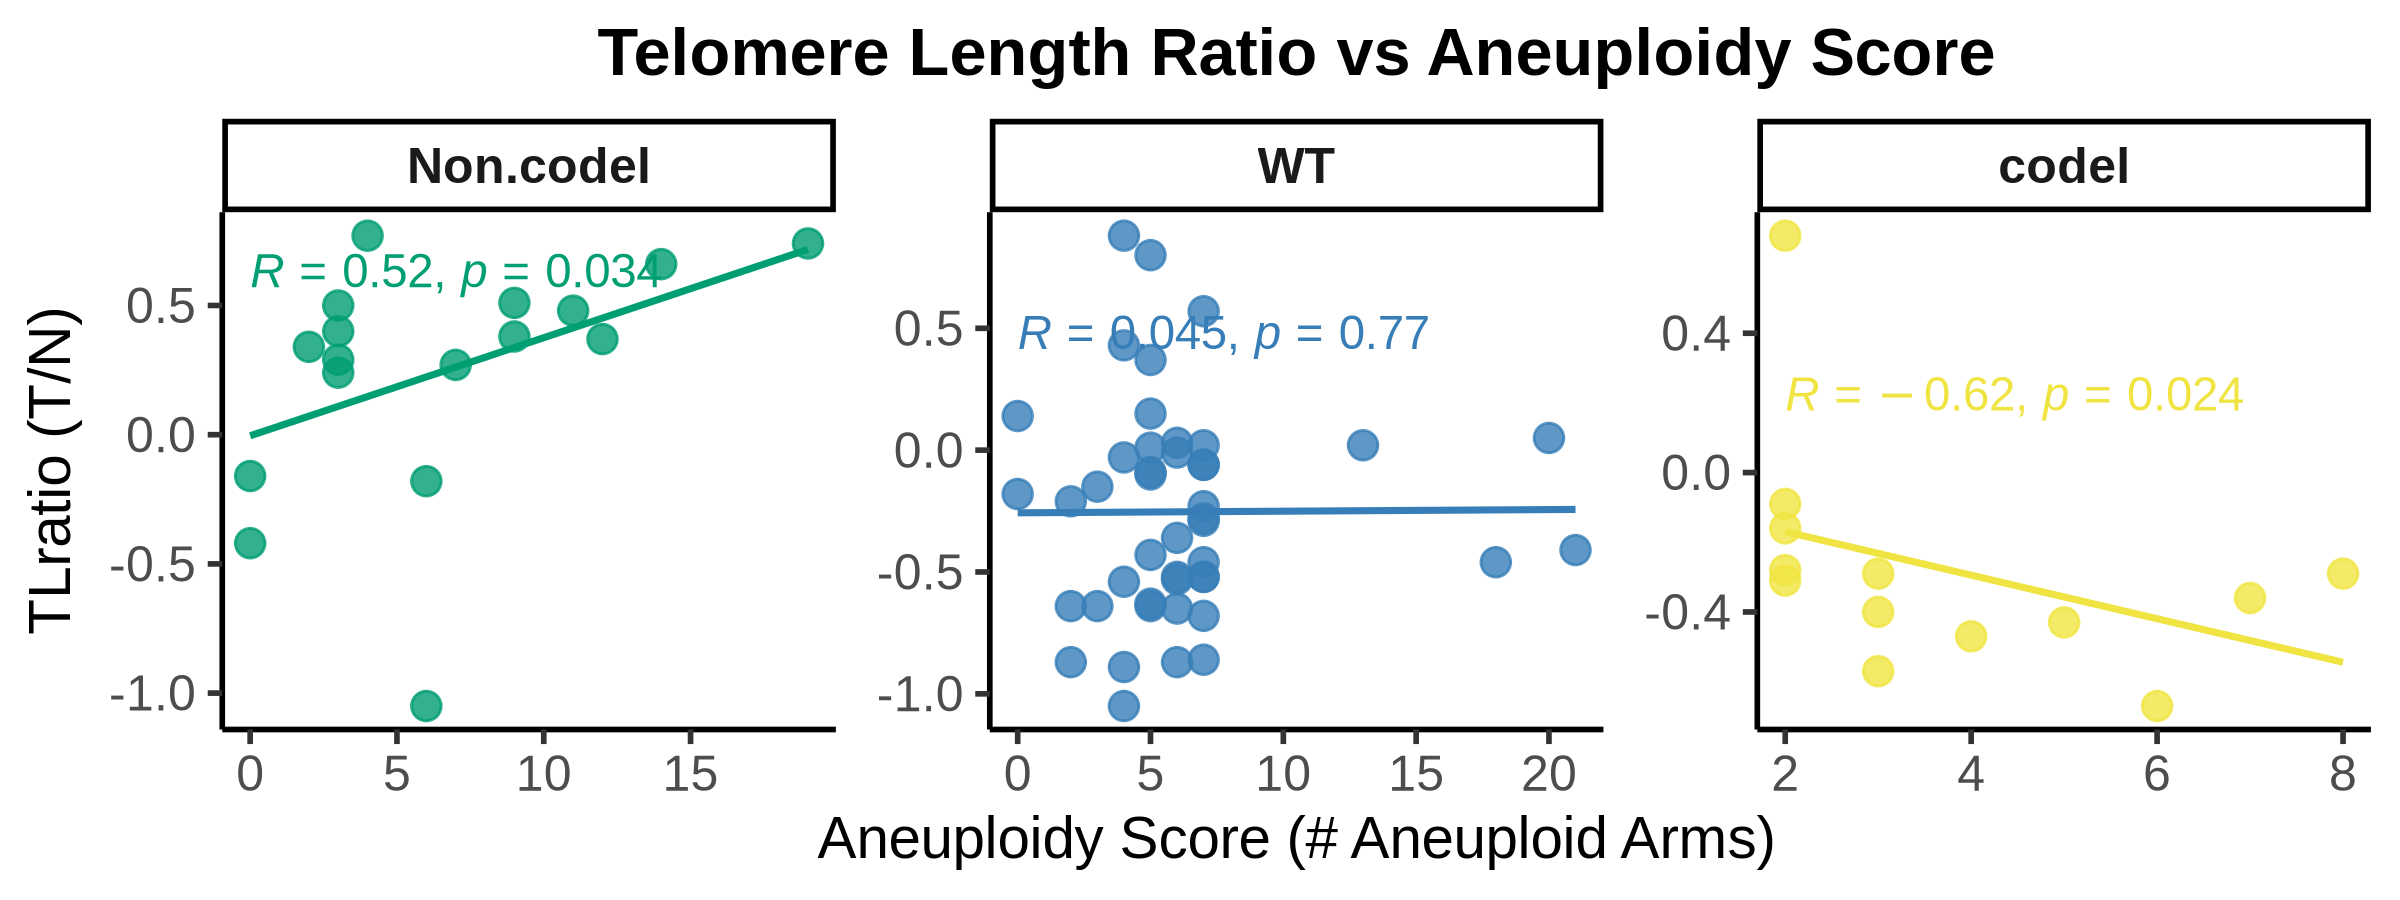

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Segmental CNV Burden (Σ fraction altered)' in 'mbcsToSbcs': for Σ (U+03A3)”


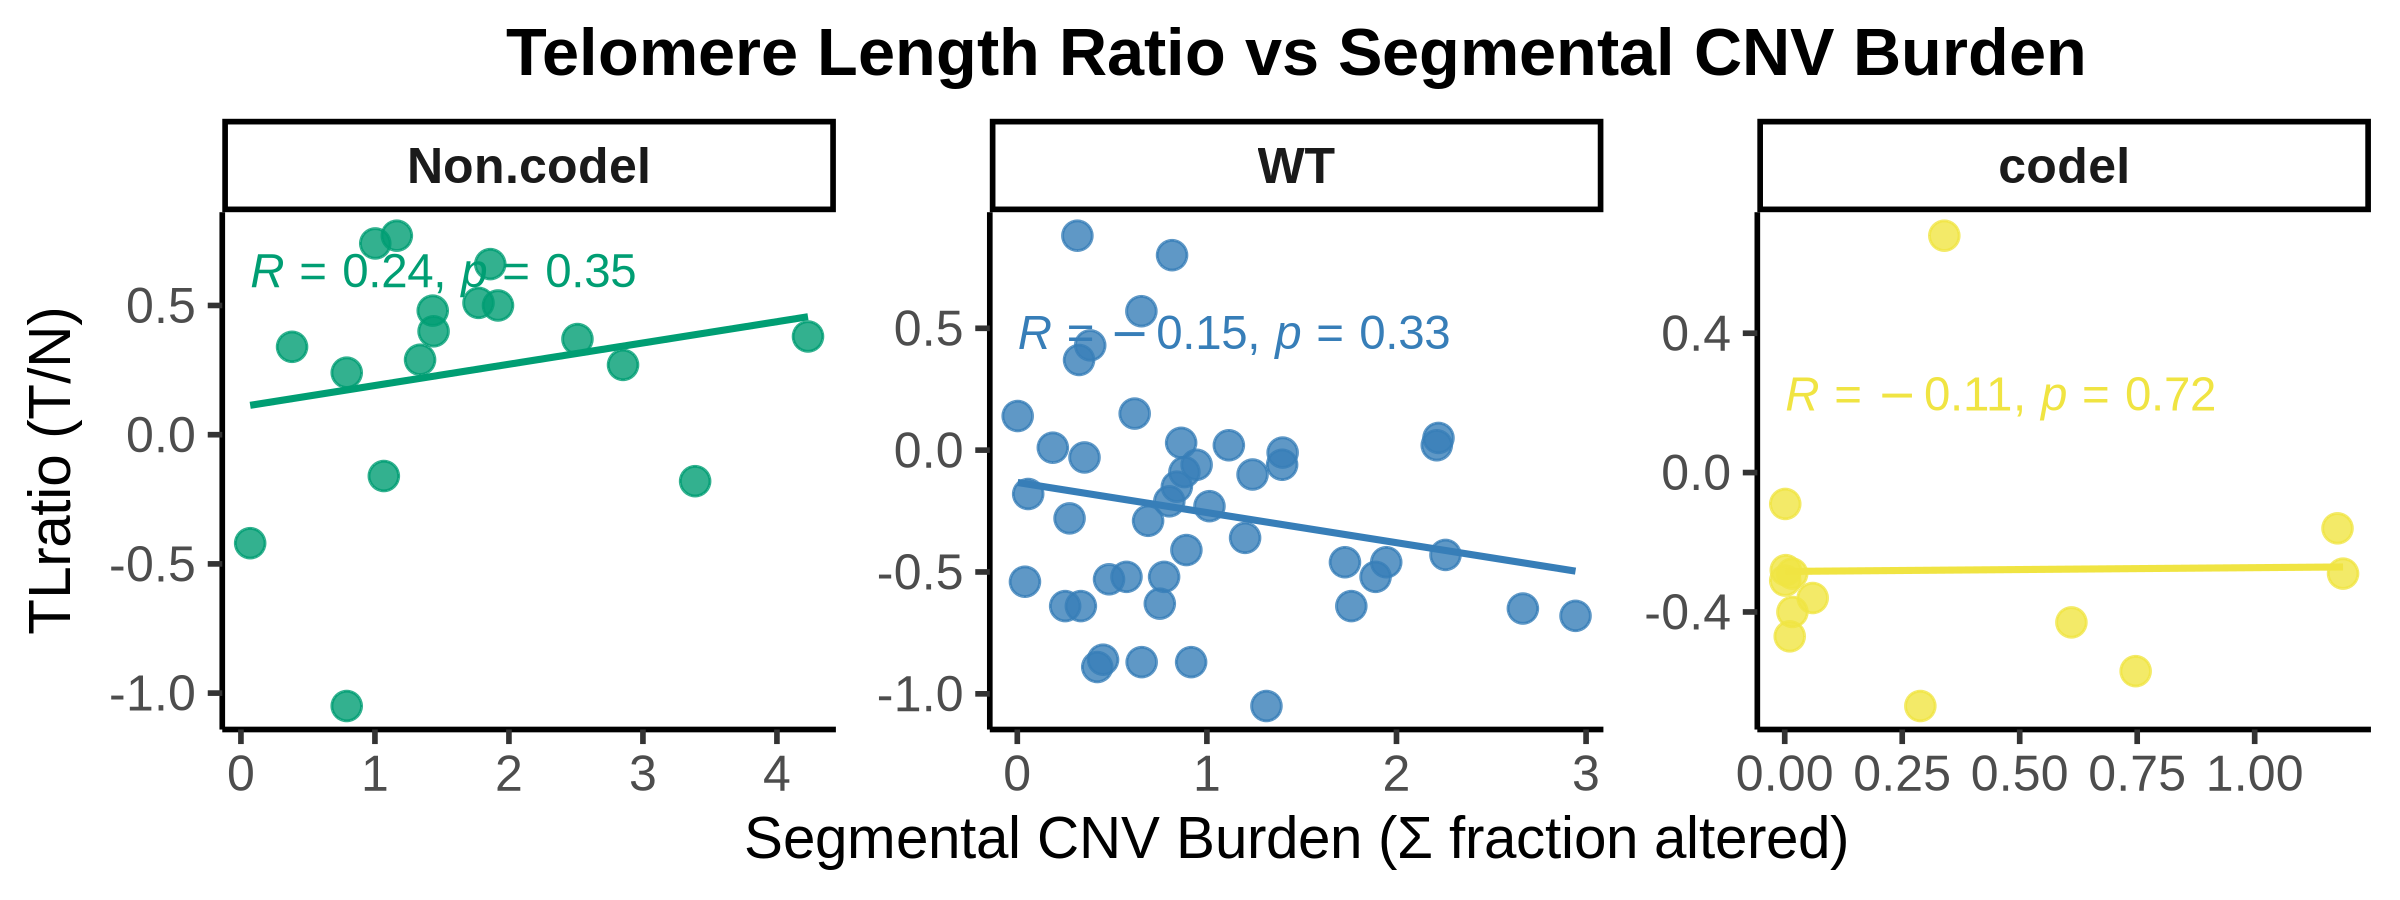

In [173]:
library(ggplot2)
library(ggpubr)

# Custom colors (same as P1)
subtype_colors <- c(
  "Non.codel" = "#009E73",
  "WT"        = "#377EB8",
  "codel"     = "#F0E442"
)

# ------------------------
# PLOT 2 — TLratio vs Aneuploidy Score
# ------------------------
p2 <- ggplot(df, aes(x = aneuploidy_score, y = TLratio, color = subtype)) +
  geom_point(size = 3, alpha = 0.8) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
  facet_wrap(~ subtype, scales = "free") +
  stat_cor(method = "spearman", label.x.npc = "left", label.y.npc = "top", size = 4) +
  scale_color_manual(values = subtype_colors) +
  labs(
    title = "Telomere Length Ratio vs Aneuploidy Score",
    x = "Aneuploidy Score (# Aneuploid Arms)",
    y = "TLratio (T/N)"
  ) +
  theme_classic(base_size = 14) +
  theme(
    strip.text = element_text(face = "bold", size = 12),
    legend.position = "none",
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5)
  )

# ------------------------
# PLOT 3 — TLratio vs Segmental CNV Burden
# ------------------------
p3 <- ggplot(df, aes(x = segmental_cnv_burden, y = TLratio, color = subtype)) +
  geom_point(size = 3, alpha = 0.8) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
  facet_wrap(~ subtype, scales = "free") +
  stat_cor(method = "spearman", label.x.npc = "left", label.y.npc = "top", size = 4) +
  scale_color_manual(values = subtype_colors) +
  labs(
    title = "Telomere Length Ratio vs Segmental CNV Burden",
    x = "Segmental CNV Burden (Σ fraction altered)",
    y = "TLratio (T/N)"
  ) +
  theme_classic(base_size = 14) +
  theme(
    strip.text = element_text(face = "bold", size = 12),
    legend.position = "none",
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5)
  )

# ------------------------
# High-resolution figure options
# ------------------------
options(repr.plot.width = 8, repr.plot.height = 3, repr.plot.res = 300)

# Display plots
p2
p3

# ------------------------
# Save figures in high-resolution
# ------------------------
ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig1/TLratio_vs_AneuploidyScore.pdf", p2, width = 8, height = 3, dpi = 600)
ggsave("/home/mjehangir/telomere-sv-analysis/plots/fig1/TLratio_vs_SegmentalCNVBurden.pdf", p3, width = 8, height = 3, dpi = 600)
#